<a href="https://www.kaggle.com/code/mahdimashayekhi/ethereum-anomaly-detection?scriptVersionId=246805424" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# !pip install category_encoders

from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ethereum-frauddetection-dataset/transaction_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/ethereum-frauddetection-dataset/transaction_dataset.csv")

In [3]:
df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [4]:
df.tail()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
9836,9836,2175,0xff481ca14e6c16b79fc8ab299b4d2387ec8ecdd2,1,12635.10,631.39,58748.48,4,13,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,,GSENetwork
9837,9837,2176,0xff718805bb9199ebf024ab6acd333e603ad77c85,1,0.00,0.00,0.00,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9838,9838,2177,0xff8e6af02d41a576a0c82f7835535193e1a6bccc,1,2499.44,2189.29,261601.88,67,43,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,,Free BOB Tokens - BobsRepair.com
9839,9839,2178,0xffde23396d57e10abf58bd929bb1e856c7718218,1,0.00,0.00,0.00,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9840,9840,2179,0xd624d046edbdef805c5e4140dce5fb5ec1b39a3c,1,37242.70,149.56,670817.33,18,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0,,INS Promo1


In [5]:
print(f"Number of rows in DataFrame is {df.shape[0]}")
print(f"Number of columns in DataFrame is {df.shape[1]}")

Number of rows in DataFrame is 9841
Number of columns in DataFrame is 51


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

In [7]:
print("Number of NaN values in each columns:\n\n", df.isnull().sum())

Number of NaN values in each columns:

 Unnamed: 0                                                 0
Index                                                      0
Address                                                    0
FLAG                                                       0
Avg min between sent tnx                                   0
Avg min between received tnx                               0
Time Diff between first and last (Mins)                    0
Sent tnx                                                   0
Received Tnx                                               0
Number of Created Contracts                                0
Unique Received From Addresses                             0
Unique Sent To Addresses                                   0
min value received                                         0
max value received                                         0
avg val received                                           0
min val sent                                 

In [8]:
print(f"Total number of NaN values is {df.isnull().sum().sum()}")

Total number of NaN values is 22635


In [9]:
print(f"Number of duplicated values in Index columns is {df.duplicated(subset='Index').sum()}")

Number of duplicated values in Index columns is 5112


In [10]:
print(f"Number of duplicated values is {df.duplicated().sum()}")

Number of duplicated values is 0


In [11]:
# Change the name of columns
df.columns = df.columns.str.strip().str.replace(r'\b\s+\b', '_', regex=True)
df.columns

Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg_min_between_sent_tnx',
       'Avg_min_between_received_tnx',
       'Time_Diff_between_first_and_last (Mins)', 'Sent_tnx', 'Received_Tnx',
       'Number_of_Created_Contracts', 'Unique_Received_From_Addresses',
       'Unique_Sent_To_Addresses', 'min_value_received', 'max_value_received',
       'avg_val_received', 'min_val_sent', 'max_val_sent', 'avg_val_sent',
       'min_value_sent_to_contract', 'max_val_sent_to_contract',
       'avg_value_sent_to_contract',
       'total_transactions (including_tnx_to_create_contract',
       'total_Ether_sent', 'total_ether_received',
       'total_ether_sent_contracts', 'total_ether_balance', 'Total_ERC20_tnxs',
       'ERC20_total_Ether_received', 'ERC20_total_ether_sent',
       'ERC20_total_Ether_sent_contract', 'ERC20_uniq_sent_addr',
       'ERC20_uniq_rec_addr', 'ERC20_uniq_sent_addr.1',
       'ERC20_uniq_rec_contract_addr', 'ERC20_avg_time_between_sent_tnx',
       'ERC20_avg_time_be

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,9841.0,4.920000e+03,2.840996e+03,0.00,2460.000000,4.920000e+03,7380.000000,9.840000e+03
Index,9841.0,1.815050e+03,1.222622e+03,1.00,821.000000,1.641000e+03,2601.000000,4.729000e+03
FLAG,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
Avg_min_between_sent_tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
Avg_min_between_received_tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
Time_Diff_between_first_and_last (Mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
Sent_tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
Received_Tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
Number_of_Created_Contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
Unique_Received_From_Addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03


In [13]:
# Show number of values in each class in percent
df['FLAG'].value_counts(normalize=True) * 100

FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64

In [14]:
df[df.duplicated(subset='Index')]['FLAG'].value_counts(normalize=True) * 100

FLAG
0    57.374804
1    42.625196
Name: proportion, dtype: float64

In [15]:
df.drop(columns=['Unnamed: 0', 'Index', 'Address'], axis=0, inplace=True)

In [16]:
categories = df.select_dtypes(include=['object']).columns

for i in categories:
    print(f"The number of unique values in {i} is {df[i].nunique()} and it has {df[i].isnull().sum()} NaN values")

The number of unique values in ERC20_most_sent_token_type is 304 and it has 2697 NaN values
The number of unique values in ERC20_most_rec_token_type is 466 and it has 871 NaN values


In [17]:
numeric = df.select_dtypes(include=['number']).columns
constant_var = [i for i in numeric if df[i].var() == 0]
print(f"Number of features that have constant value is {len(constant_var)}")
constant_var

Number of features that have constant value is 7


['ERC20_avg_time_between_sent_tnx',
 'ERC20_avg_time_between_rec_tnx',
 'ERC20_avg_time_between_rec_2_tnx',
 'ERC20_avg_time_between_contract_tnx',
 'ERC20_min_val_sent_contract',
 'ERC20_max_val_sent_contract',
 'ERC20_avg_val_sent_contract']

In [18]:
# Drop constant variance features
df.drop(columns=constant_var, axis=0, inplace=True)

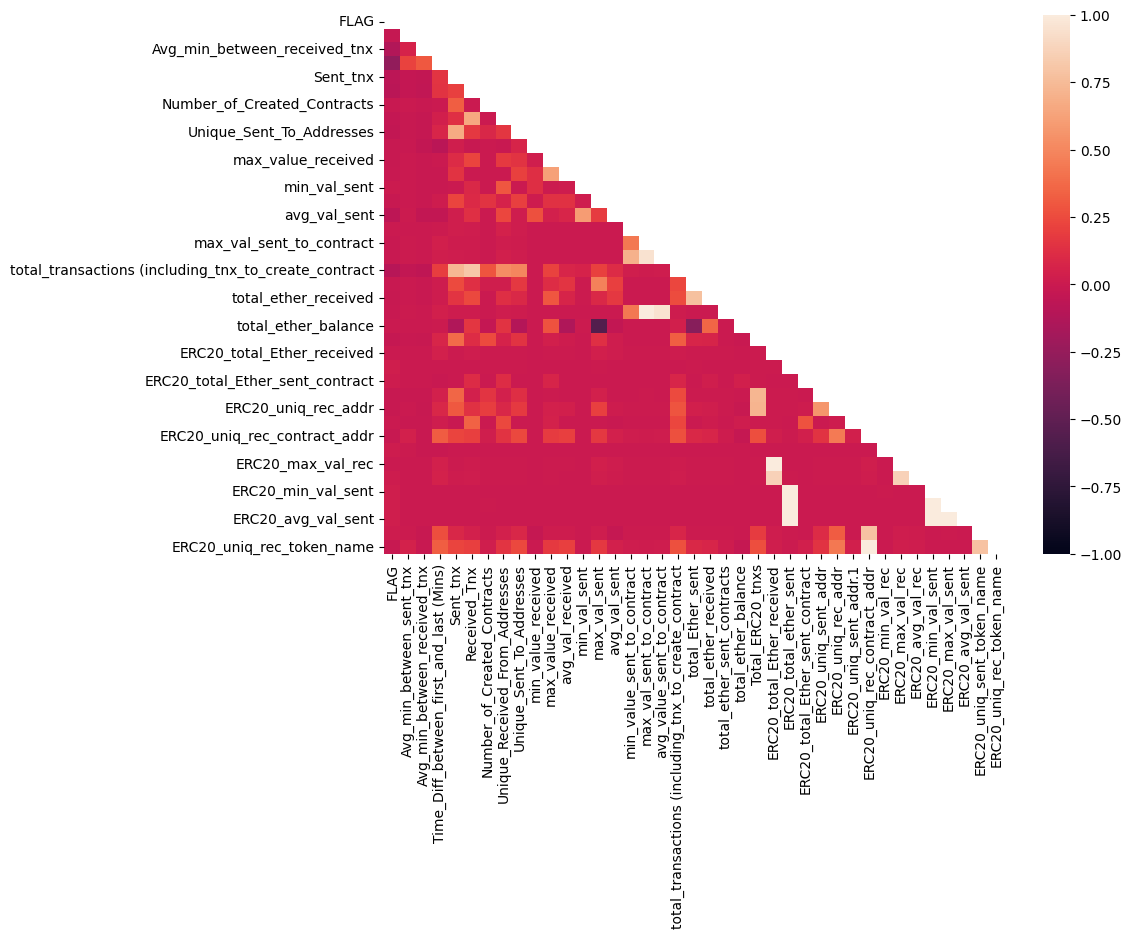

In [19]:
plt.figure(figsize=(10, 7))
numeric = df.select_dtypes(include=['number']).columns
corr = df[numeric].corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=False, vmin=-1, vmax=1)
plt.show()

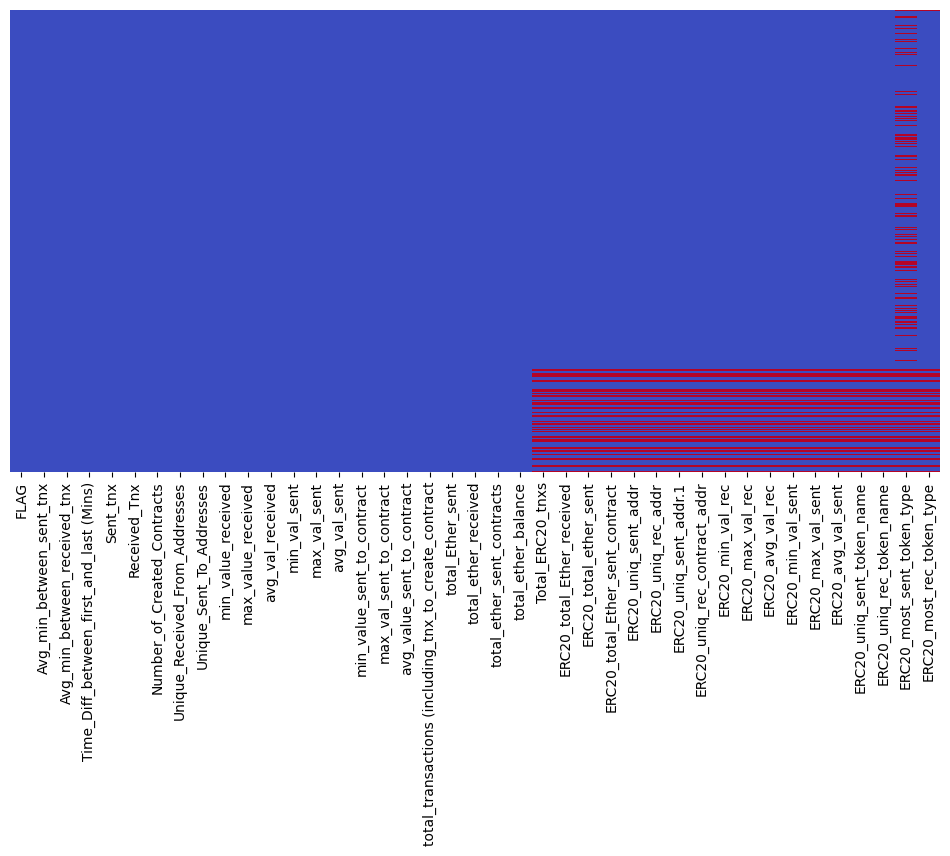

In [20]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap='coolwarm', cbar=False)
plt.yticks([])
plt.show()

In [21]:
print(f"Number of rows that has at least one missing value: {df.isnull().any(axis=1).sum()}")
missing_mask = df.isnull().any(axis=1)

Number of rows that has at least one missing value: 2720


In [22]:
print(df.loc[missing_mask, 'FLAG'].value_counts())
print()
print(round(df.loc[missing_mask, 'FLAG'].value_counts(normalize=True), 2) * 100)

FLAG
0    1891
1     829
Name: count, dtype: int64

FLAG
0    70.0
1    30.0
Name: proportion, dtype: float64


In [23]:
print(df['FLAG'].value_counts())
print()
print(round(df['FLAG'].value_counts(normalize=True), 2) * 100)

FLAG
0    7662
1    2179
Name: count, dtype: int64

FLAG
0    78.0
1    22.0
Name: proportion, dtype: float64


In [24]:
print(df[~missing_mask].shape)
sub_df = df[~missing_mask]

(7121, 41)


In [25]:
# Split the data into train and test set
X = sub_df.drop(columns='FLAG', axis=1)
y = sub_df['FLAG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
print(f"Shape of X_train is {X_train.shape}")
print(f"Shape of y_train is {y_train.shape}")
print(f"Shape of X_test is {X_test.shape}")
print(f"Shape of y_test is {y_test.shape}")

Shape of X_train is (5696, 40)
Shape of y_train is (5696,)
Shape of X_test is (1425, 40)
Shape of y_test is (1425,)


In [27]:
encoder = TargetEncoder(cols=categories)
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

In [28]:
train = pd.concat([X_train_encoded, y_train], axis=1)
test  = pd.concat([X_test_encoded, y_test], axis=1)

In [29]:
model = IsolationForest(contamination=0.01, random_state=42)
model.fit(train)

IsolationForest(contamination=0.01, random_state=42)

In [30]:
anomaly_train_pred = model.predict(train)
anomaly_test_pred = model.predict(test)

is_train = np.sum(anomaly_train_pred == -1)
is_test = np.sum(anomaly_test_pred == -1)

print(f"Number of outliers in training set is {is_train}")
print(f"Number of outliers in testing set is {is_test}")

Number of outliers in training set is 57
Number of outliers in testing set is 9


In [31]:
t_sne = TSNE(n_components=2, random_state=42)
X_train_embeded = t_sne.fit_transform(X_train_encoded)

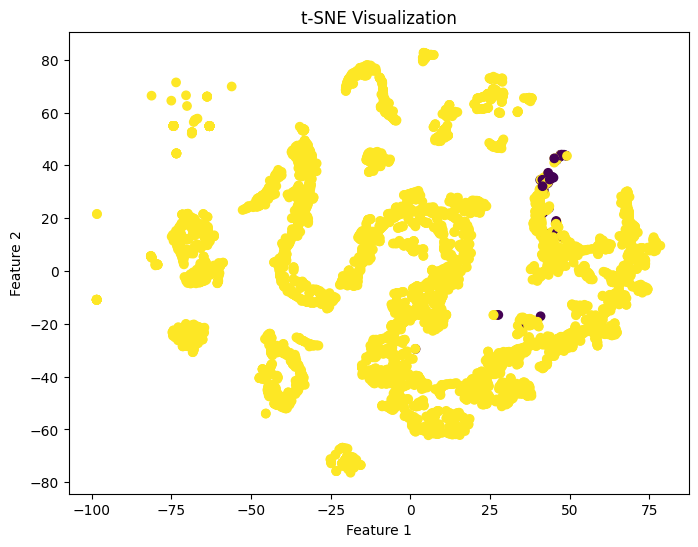

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(x = X_train_embeded[:, 0], y = X_train_embeded[:, 1], c=anomaly_train_pred)
plt.title('t-SNE Visualization')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [33]:
X_test_embeded = t_sne.fit_transform(X_test_encoded)

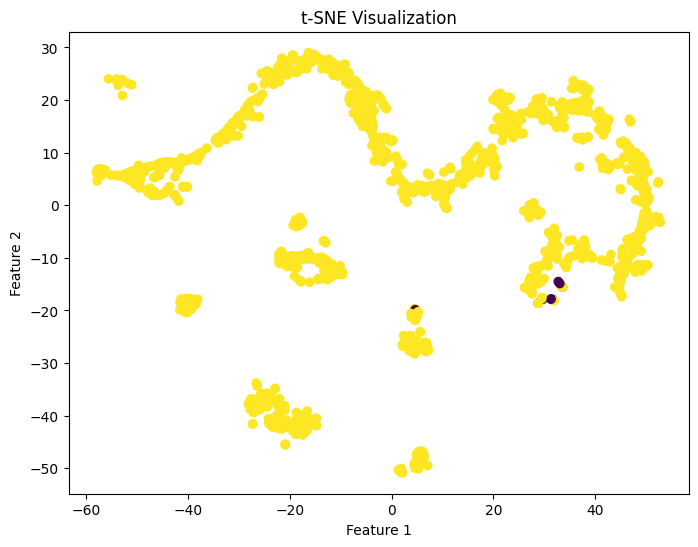

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(x = X_test_embeded[:, 0], y = X_test_embeded[:, 1], c=anomaly_test_pred)
plt.title('t-SNE Visualization')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()